<a href="https://colab.research.google.com/github/fenniyaangel/Analisis-Deret-Waktu/blob/main/Tugas_Praktikum_Minggu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fenniya Angel Lee M0501261094

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [66]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1094)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5*94
beta0 = 10+94
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


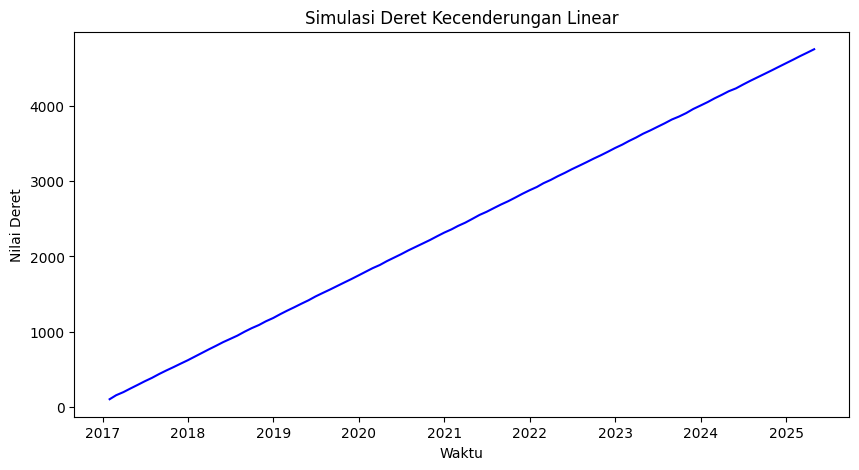

In [67]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Berdasarkan plot yang menunjukkan adanya tren, korelasi antar pengamatan terlihat memiliki kecenderungan linear naik yang sangat dominan. Karena nilainya terus naik, maka nilai pada waktu t cenderung bergantung pada nilai waktu sebelumnya, yaitu waktu t-1, sehingga berindikasi terdapat korelasi antar pengamatannya.

Agar dapat dilakukan analisis yang lebih mendalam, dapat dibuat plot ACF (Autocorrelation Function) pada syntax berikut. Berdasarkan plot tersebut, dapat terlihat garis vertikal yang perlahan membentuk garis miring atau slow decay. Pada lag awal, garisnya berada di luar area bayangan biru muda. Bahkan pada lag 1, nilai korelasi yang terlihat adalah sebesar 1. Hal ini merupakan bukti visual yang menunjukkan bahwa terdapat korelasi yang tinggi dan signifikan antara suatu pengamatan dengan pengamatan-pengamatan sebelumnya.

Berdasarkan nilai korelasi pearson pada code berikutnya, output df["Time_Numeric"].corr(df["Value"]), mendapatkan hasil korelasi sebesar 1.0000. Ini mengonfirmasi bahwa nilai deret waktu memiliki hubungan linear yang nyaris sempurna dengan waktu pengamatannya.

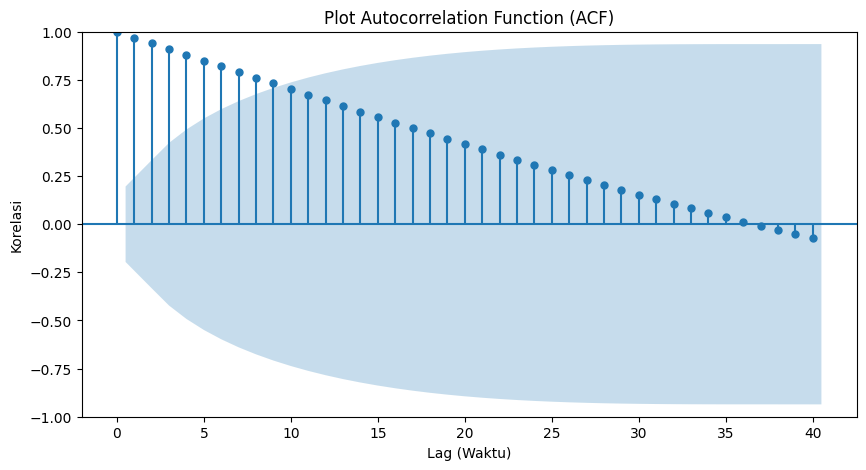

In [68]:
import statsmodels.api as sm

fig, ax = plt.subplots(figsize=(10, 5))
# df['Value'] adalah kolom data dari dataframe yang sudah kamu buat sebelumnya
sm.graphics.tsa.plot_acf(df['Value'], lags=40, ax=ax)
plt.title("Plot Autocorrelation Function (ACF)")
plt.xlabel("Lag (Waktu)")
plt.ylabel("Korelasi")
plt.show()

In [70]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [71]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.912e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.81e-276
Time:                        16:22:09   Log-Likelihood:                -218.32
No. Observations:                 100   AIC:                             440.6
Df Residuals:                      98   BIC:                             445.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          103.9055      0.431    241.295   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Nilai parameter asli beta 0 adalah 94+10=104. Hasil pengepasan model regresi menunjukkan nilai koefisien constanta (pada tabel Hasil Regresi OLS) adalah 103.9055. Nilai parameter asli beta 1 adalah 0.5*94=47. Sementara itu, hasil pengepasan model regresinya menunjukkan nilai 47.0005. Berdasarkan kedua parameter ini dapat disimpulkan bahwa nilai pengepasan parameter model regresi yang dihasilkan sangat akurat dan hampir persis sama dengan parameter asli yang didefinisikan di awal simulasi.


Apakah model regresi yang dipaskan sudah bagus?

Sangat bagus. Berdasarkan tabel hasil OLS Regression, dapat terlihat bahwa R-squared bernilai 1. Hal ini berarti bahwa model regresi linear yang dipaskan sudah dapat menjelaskan 100% variabilitas dari nilai deret waktu tersebut, yang menunjukkan bahwa fitting yang dilakukan model regresi sudah sangat baik.
Selain itu, nilai Prob (F-statistic) yang dihasilkan mendekati 0 (di bawah alpha = 0.05), yang berarti secara keseluruhan, model ini sangat signifikan secara statistik.
Nilai p-value untuk kedua parameter bernilai 0.000, menunjukkan bahwa baik intersep maupun variabel waktu (Time_Numeric) berpengaruh signifikan terhadap nilai deret.
Nilai Durbin-Watson sebesar 1.876. Nilai ini dekat dengan angka 2. Dalam analisis regresi, nilai Durbin-Watson di sekitar 2 menunjukkan bahwa tidak ada autokorelasi pada sisaan atau residual model. Artinya, regresi ini sudah berhasil menangkap seluruh tren waktu dengan baik, dan sisa dari model tersebut hanya berupa noise acak.


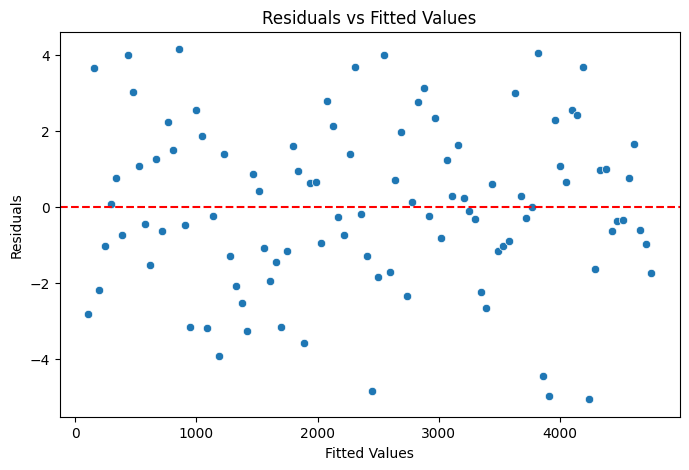

In [72]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

Garis putus-putus merupakan kondisi target dari model dimana nilai residual bernilai 0. Sementara itu, titik-titik pada plot tersebut merupakan residual atau selisih antara nilai aktual dan nilai prediksi. Titik-titik pada plit tersebut menyebar secara random di atas dan di bawah garis merah. Pada titik-titik tersebut juga tidak terlihat ada pola sistematis, seperti pola melebar, menyempit, melengkung, dan lainnya.Hal ini menunjukkan bahwa asumsi linearitas terpenuhi, yaitu hubungan antara waktu dan nilai deret adalah linear sehingga tidak ada pola non linier yang tertinggal pada sisaan. Selain itu terdapat juga indikasi homoskedasitias yaitu ketika varians dari sisaan tamapk konstan di berbagai tingkat nilai prediksi.

In [73]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.7998


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

Uji Breusch Pagan digunakan untuk mengecek homoskedastisitas, dengan hipotesis:
H0 : Varians sisaan konstan (Terjadi homoskedastisitas).
H1 : Varians sisaan tidak konstan.

Pada output syntax sebelumnya, didapatkan nilai p-value dari uji Breusch Pagan sebesar 0.7998. Karena nilai p-value > alpha (alpha = 0.05), maka disimpulkan bahwa gagal menolak H0. Dengan demikian, berdasarkan uji Breusch Pagan, dapat disimpulkan bahwa asumsi homoskedastisitas terpenuhi.

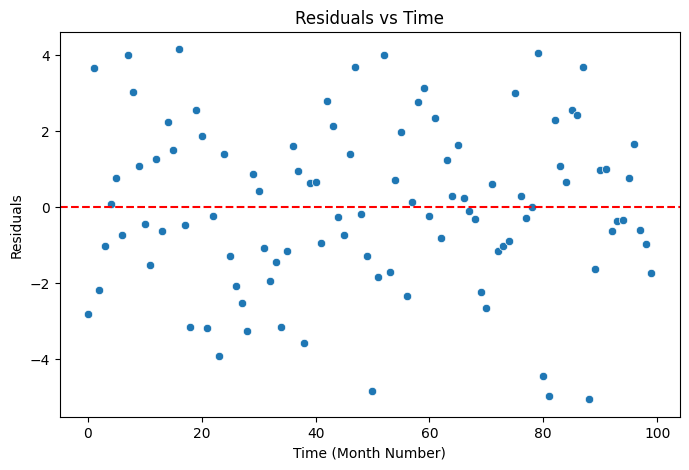

In [74]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

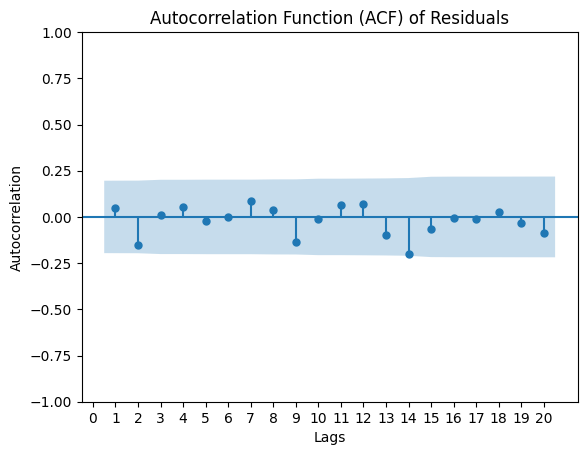

In [75]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

Plot ini merupakan plot ACF dari residual model regresi yang telah dipaskan sebelumnya. Dapat terlihat bahwa semua titik dari lag 1 dan seterusnya berada di dalam area berwarna biru. Hal ini menunjukkan tidak ada autokorelasi yang signifikan pada residual model regresi di lag mana pun. Dengan demikian, residual sudah sepenuhnya acak dan berupa white noise. Dapat disimpulkan bahwa model regresi linear yang telah dipaskan sebelumnya sudah sangat baik dalam menangkap pola tren waktu yang pada data awal.

In [76]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.257110   0.612113
2    2.685675   0.261104
3    2.698932   0.440409
4    3.031604   0.552550
5    3.080252   0.687615
6    3.080325   0.798700
7    3.855106   0.796307
8    4.005120   0.856661
9    6.151501   0.724665
10   6.160626   0.801592
11   6.627866   0.828370
12   7.190097   0.844800
13   8.341926   0.820633
14  12.996471   0.526802
15  13.489319   0.564558
16  13.495472   0.636244
17  13.519377   0.700783
18  13.617595   0.753658
19  13.776296   0.796572


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Uji ini dilakukan untuk mengecek autokorelasi pada residual, yaitu apakah residual saling bebas atau tidak.
H0 : Tidak ada autokorelasi pada residual.
H1 : Terdapat autokorelasi pada residual.

Hasil dari uji ini dapat terlihat bahwa pada lag 1 hingga lag 19, nilai p-value yang dihasilkan lebih besar dari alpha (alpha = 0.05), sehingga gagal menolak H0. Dengan demikian, dapat disimpulkan tidak terdapat autokorelasi yang signifikan pada residual model (sisaan saling bebas). Nilai-nilai sisaan tersebut sudah merupakan white noise.

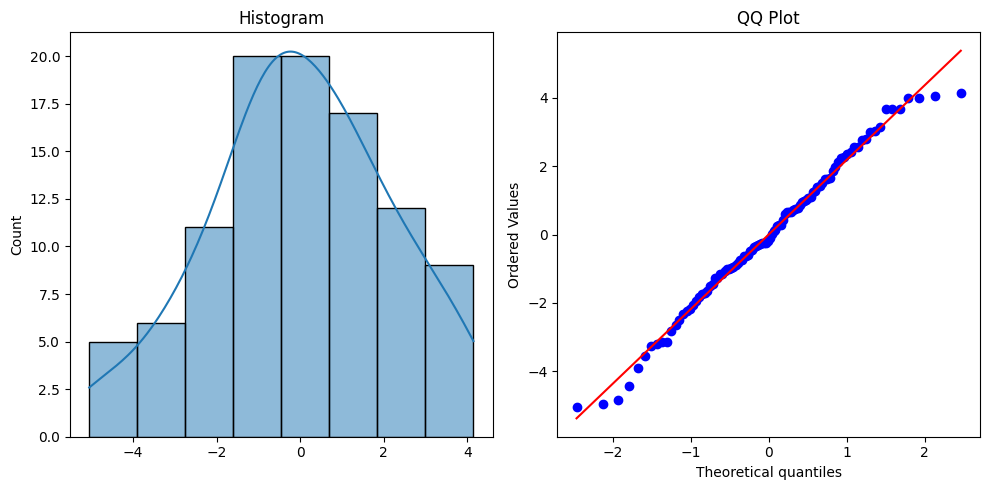

In [77]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

Pada plot histogram, batang-batang penyebaran sisaan tersebut membentuk pola kurva lonceng yang cukup simetris di sekitar angka 0 secara visual. Garis lengkung biru, yang merupakan kurva kepadatan estimasi, juga sangat menyerupai bentuk distribusi normal standar.

Berdasarkan gambar QQ Plot (Quantile-Quantile Plot), titik-titik biru yang merupakan titik data sisaan mengikuti garis lurus diagonal berwarna merah dengan sangat rapat secara keseluruhan. Garis merah tersebut merepresentasikan distribusi normal secara teoretis. Karena titik-titiknya tidak melenceng jauh menjauhi garis merah, maka hal ini adalah indikasi kuat secara visual bahwa data sisaan tersebut berdistribusi normal.

In [78]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9868051360109079, p-value = 0.42465596032638464


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Ya, kesimpulannya sama. Uji Shapiro Wilk meiliki hipotesis sebagai berikut.
H0 : Sisaan berdistribusi normal.
H1 : Sisaan tidak berdistribusi normal.
Nilai p-value yang didapatkan adalah 0.425, di mana nilai tersebut lebih besar dari tingkat signifikansi alpha 0.05, sehingga gagal menolak H0. Dengan demikian, dapat disimpulkan bahwa sisaan berdistribusi normal berdasarkan uji Shapiro Wilk.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [79]:
# Menentukan parameter simulasi
np.random.seed(1094)
n_periods = 120
beta_0, beta_1, beta_2= 50+94, 0.5*94, 0.02*94
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

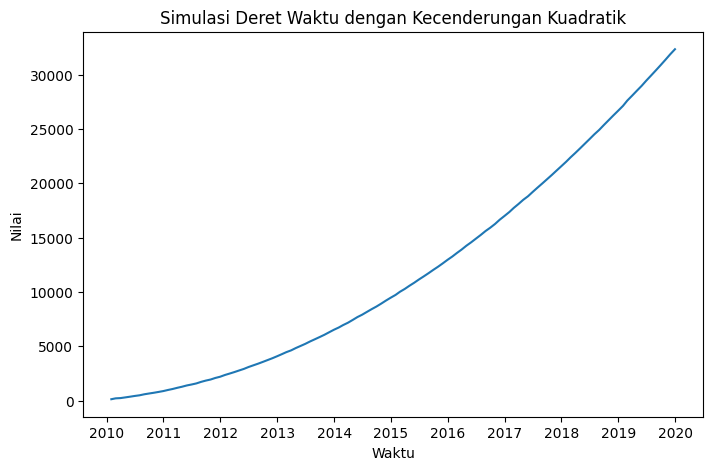

In [80]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Berdasarkan plot simulasi deret waktu dengan kecenderungan kuadratik, deret waktu tersebut menunjukkan tren naik yang sangat kuat dan tidak stasioner. Nilai deret terus bertambah seiring berjalannya waktu dari tahun 2010 hingga awal 2020. Kenaikan yang terjadi tidak secara konstan, melainkan semakin lama semakin cepat. Hal ini terlihat jelas dari bentuk grafik yang melengkung tajam ke atas menyerupai kurva eksponensial.

Pola kecenderungan linear memiliki perubahan nilai pada tingkat yang konstan di tiap waktunya. Grafik yang dihasilkan berupa garis lurus. Sementara itu, pola kecenderungan kuadratik memiliki pertumbuhan nilai yang tidak konstan, namun bertumbuh secara eksponensial yaitu semakin lama semakin cepat. Grafik yang dihasilkan berupa garis lengkung. Kenaikan di periode awal jauh lebih kecil dibandingkan dengan di periode akhir. Pada periode akhir, lonjakan nilainya menjadi sangat drastis.

In [81]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.735e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:27:19   Log-Likelihood:                -454.27
No. Observations:                 120   AIC:                             914.5
Df Residuals:                     117   BIC:                             922.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        143.3431      2.908     49.286      0.0

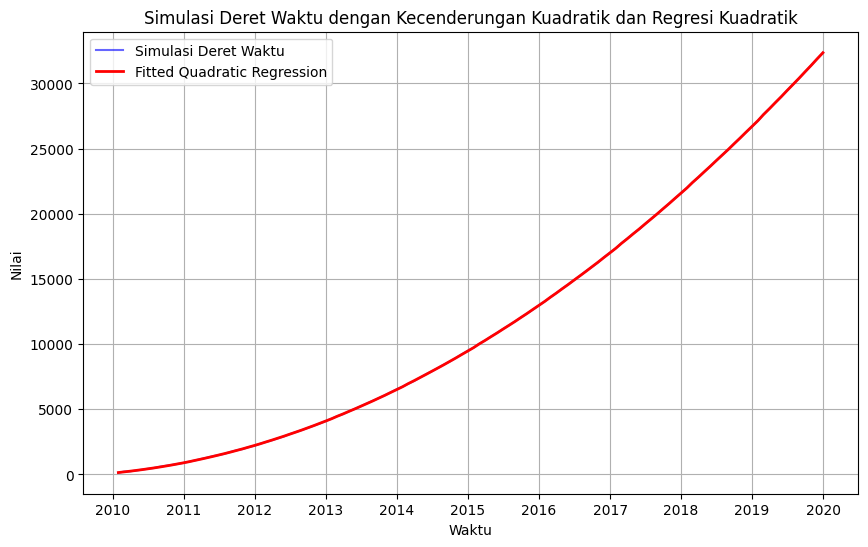

In [82]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

- Pada plot Residuals vs Fitted Values, titik-titik menyebar secara acak di atas dan di bawah garis merah (garis saat residual = 0) tanpa membentuk pola khusus. Dengan demikian, asumsi homoskedesitias (ragam sisaan konstan) terpenuhi.
- Pada plot histogram sisaan, histogram membentuk kurva lonceng yang cukup simetris, menyerupai distribusi normal. Dengan demikian, secara visual asumsi normalitas sisaan terpenuhi.
- Pada QQ plot, titik-titik pada QQ Plot mengikuti garis lurus diagonal merah dengan sangat rapat. Dengan demikian, secara visual asumsi normalitas sisaan terpenuhi.
- Nilai P-value Uji Shapiro-Wilk adalah 0.3998. Karena nilainya jauh di atas tingkat signifikansi = 0.05, maka gagal menolak H0. Dengan demikian, berdasarkan uji Shapiro-Wilk asumsi normalitas sisaan terpenuhi.
- Nilai P-value Uji Breusch-Pagan adalah 0.9035. Karena nilainya lebih besar dari tingkat signifikansi = 0.05, maka gagal menolak H0. Dengan demikian, berdasarkan uji Breusch-Pagan asumsi homoskedesitias (ragam sisaan konstan) terpenuhi.
- Pada plot ACF, seluruh garis vertikal dari lag awal hingga akhir berada di dalam area batas signifikansi (area berwarna biru). Hal ini menunjukkan tidak terdapat autokorelasi pada sisaan. Nilai-nilai error pada model ini sudah sepenuhnya acak dan merupakan white noise. Dengan demikian, asumsi sisaan saling bebas (tidak terdapat autokorelasi) telah terpenuhi.
- Nilai P-value Uji Ljung-Box pada lag 20 adalah 0.7741. Nilai ini lebih besar dari tingkat signifikansi = 0.05, ini berarti kesimpulan yang diambil adalah gagal menolak H0. Dengan demikian, asumsi sisaan saling bebas (tidak terdapat autokorelasi) telah terpenuhi.


Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Berdasarkan output yang ada pada gambar-gambar sebelumnya, model yang dipaskan terhadap deret sudah sangat tepat.

Pada tabel regresi OLS, nilai R-squared adalah 1.000. Artinya, model regresi kuadratik ini mampu menjelaskan 100% variabilitas dari deret waktu tersebut. Nilai Prob (F-statistic) adalah 0.00, yang membuktikan bahwa model ini sangat signifikan secara statistik. Nilai Durbin-Watson sebesar 1.915, yang mana nilai ini berada sangat dekat dengan 2, yang memberikan indikasi kuat bahwa sisaan model tersebut sudah terbebas dari masalah autokorelasi.

Pada plot hasil simulasi, garis merah (Fitted Quadratic Regression) berhimpit secara sempurna dengan garis biru (Simulasi Deret Waktu). Hal ini menunjukkan model berhasil menangkap seluruh pola lengkungan data.

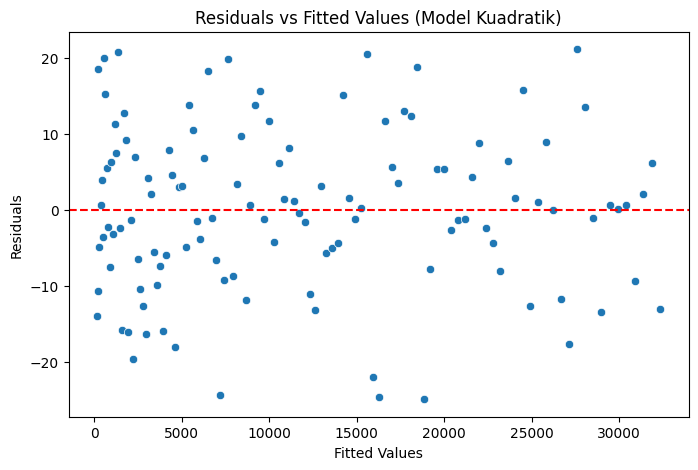

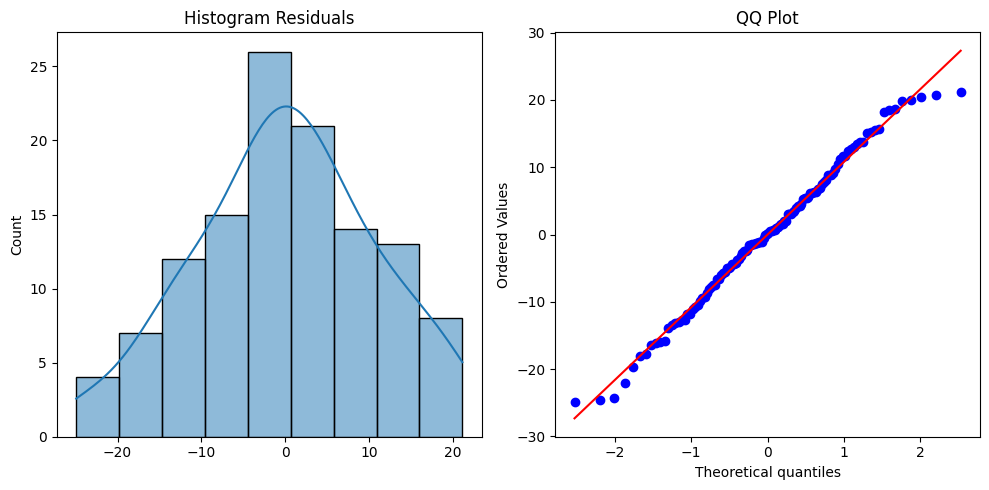

P-value Uji Shapiro-Wilk: 0.3998
P-value Uji Breusch-Pagan: 0.9035


<Figure size 800x500 with 0 Axes>

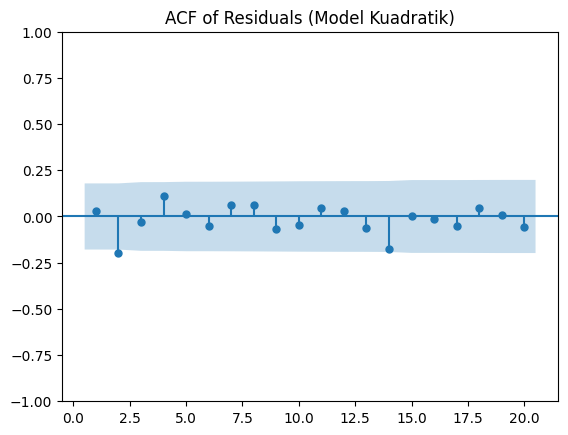

P-value Ljung-Box (Lag 20): 0.7741


In [83]:
# cek asumsi model regresi kuadratik

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# 1. Plot Residuals vs Fitted (Cek Linearitas & Homoskedastisitas visual)
plt.figure(figsize=(8,5))
sns.scatterplot(x=model_quad.fittedvalues, y=model_quad.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residuals vs Fitted Values (Model Kuadratik)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# 2. Uji Normalitas (Visual dan Shapiro-Wilk)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(model_quad.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram Residuals')
stats.probplot(model_quad.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(model_quad.resid)
print(f"P-value Uji Shapiro-Wilk: {shapiro_p:.4f}")

# 3. Uji Homoskedastisitas (Breusch-Pagan)
bp_test = het_breuschpagan(model_quad.resid, model_quad.model.exog)
print(f"P-value Uji Breusch-Pagan: {bp_test[1]:.4f}")

# 4. Uji Autokorelasi (Plot ACF dan Ljung-Box)
plt.figure(figsize=(8,5))
plot_acf(model_quad.resid, lags=20, zero=False)
plt.title("ACF of Residuals (Model Kuadratik)")
plt.show()

ljung_box = acorr_ljungbox(model_quad.resid, lags=[20], return_df=True)
print(f"P-value Ljung-Box (Lag 20): {ljung_box['lb_pvalue'].values[0]:.4f}")

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [85]:
# Menentukan parameter simulasi
np.random.seed(1094)
n_periods = 120
beta0, beta1, beta2=50+94,-25*94, -2*94
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


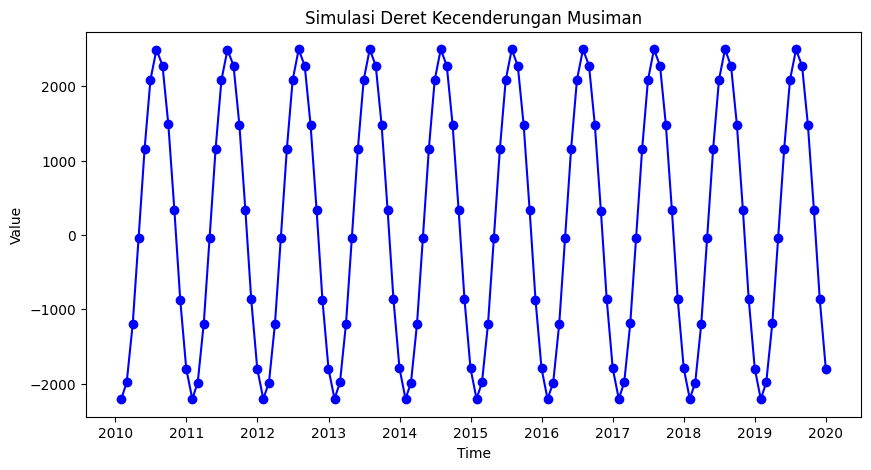

In [ ]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Pola dalam deret ini menunjukkan fluktuasi yang berulang secara teratur membentuk pola gelombang. Karena periode musimannya ditetapkan sebesar 12, ini berarti satu siklus penuh terjadi persis setiap 12 unit waktu dalam satu tahunnya. Maka dapat dikatakan pola ini berulang setiap satu tahun, dimana terjadi perubahaan kondisi tiap bulannya hingga terjadi satu siklus. Grafik ini tidak memiliki tren jangka panjang, yang berarti tidak ada kecenderungan jangka panjang bagi data untuk terus menanjak naik atau menurun. Tren grafik ini bergerak secara horizontal mendatar dari tahun 2010 hingga 2020. Selain itu, ketinggian puncak dan kedalaman lembah juga relatif konstan serta tidak melebar atau menyempit seiring berjalannya waktu. Pola gelombang ini merupakan representasi visual dari fungsi trigonometri kosinus dan sinus yang digunakan untuk membangun variabel seasonal_component sebelumnya.

In [86]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [87]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [88]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [89]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.551e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.60e-309
Time:                        16:28:59   Log-Likelihood:                -255.88
No. Observations:                 120   AIC:                             535.8
Df Residuals:                     108   BIC:                             569.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -2206.2205      0.680  -3242.944      0.0

Bagaimana interpretasi dari hasil tersebut?

Pada tabel hasil OLS Regression, nilai koefisien untuk setiap bulannya pada tabel menyatakan nilai harapan rata-rata yang merupakan estimasi nilai aktual dari deret waktu pada bulan yang bersangkutan. Misalnya, rata-rata nilai deret pada bulan Januari adalah -2206.2205. Dengan demikian, pada pergerakan nilai koefisien dari Januari hingga Desember dalam tabel, pola gelombang atau siklik yang dibahas sebelumnya terlihat sangat jelas dalam bentuk angka. Deret ini mencapai titik terendahnya di awal tahun, yaitu pada bulan Januari (-2206.2205). Nilainya kemudian merangkak naik, menembus angka positif antara bulan April dan Mei, lalu mencapai puncaknya pada pertengahan tahun di bulan Juli (2494.3461). Setelah Juli, nilainya berangsur-angsur turun kembali menuju akhir tahun di bulan Desember (-1797.4888).

Pada kolom P>|t|, yang menyatakan p-value, semua bulan memiliki p-value sebesar 0.000. Hal ini berarti efek musiman pada setiap bulan secara statistik sangat signifikan. Nilai R-squared sebesar 1.000 menandakan bahwa 100% variabilitas dalam data simulasi tersebut berhasil dijelaskan oleh komponen musimannya. Hal ini menunjukkan bahwa model sangat cocok dengan data. Nilai Durbin-Watson sebesar 1.873, yang sangat dekat dengan 2, juga mengonfirmasi bahwa sisaan dari model ini terbebas dari masalah autokorelasi.

In [90]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

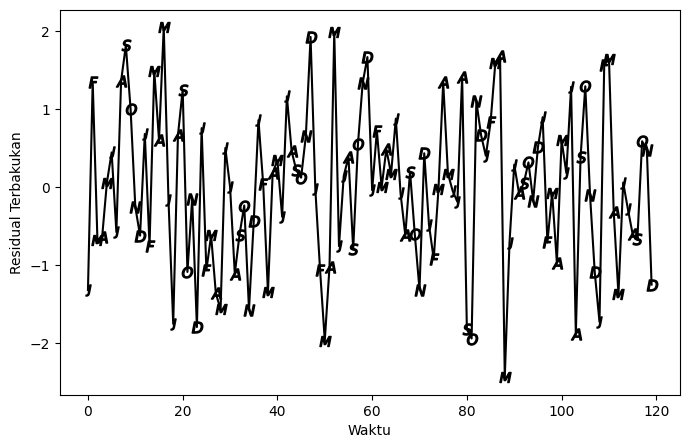

In [91]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


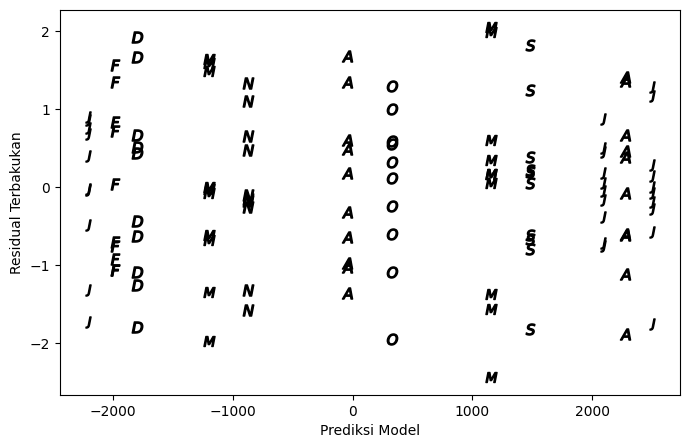

In [92]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

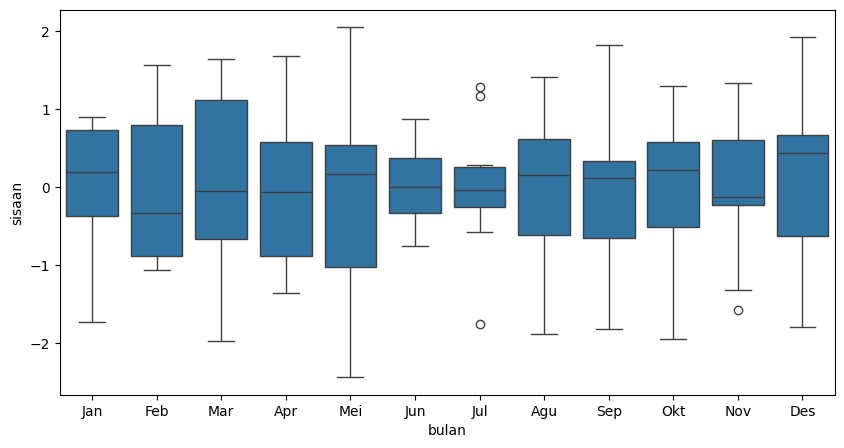

In [93]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

Pada plot residual terbarukan vs waktu, titik-titik residual yang ditandai dengan huruf awal bulan bergerak naik-turun secara acak di rentang sekitar -2 hingga 2 sepanjang waktu pengamatan (dari 0 hingga 120 titik waktu atau setara 10 tahun). Plot ini menunjukkan bahwa tidak ada pola sistematis yang tersisa pada deret tersebut seiring berjalannya waktu, tidak ada tren sisa yang tertinggal, dan tidak ada pengulangan pola gelombang. Fluktuasi yang sepenuhnya acak (white noise) ini menandakan bahwa variabel dummy musiman telah berhasil menyerap seluruh pola siklik yang ada pada data aslinya.

Pada plot residual terbarukan vs prediksi model, titik-titik residual terlihat mengelompok membentuk kolom-kolom vertikal. Pola ini sangat wajar karena nilai prediksi hanya didasarkan pada variabel dummy kategorik. Akibatnya, model ini hanya memprediksi 12 nilai unik, yaitu nilai rata-rata dari masing-masing bulan. Pada plot ini bisa dilihat bahwa rentang sebaran titik dari atas ke bawah pada masing-masing kolom vertikal terlihat relatif seragam. Titik-titik ini tidak menyebar membentuk pola melebar maupun menyempit, sehingga dapat menjadi indikasi visual yang kuat bahwa asumsi homoskedastisitas (ragam sisaan konstan) pada model ini terpenuhi.

Berdasarkan boxplot yang terbentuk, garis horizontal di dalam kotak tiap bulannya berada dekat dengan angka 0. Hal ini berarti secara rata-rata, model ini tidak secara sistematis over predicting atau under predicting pada bulan-bulan tertentu.

Akurasi per Musim: Garis horizontal di dalam hampir semua kotak (nilai median sisaan) berada sangat dekat dengan garis batas angka 0. Ini berarti, secara rata-rata, modelmu terkalibrasi dengan seimbang dan tidak secara sistematis menebak terlalu tinggi (over-predicting) atau terlalu rendah (under-predicting) pada bulan-bulan tertentu. Interquartile Range dan panjang garis whiskers relatif sebanding antar bulan. Meskipun terdapat beberapa bulan dengan sebaran sedikit lebih lebar atau memunculkan outlier, secara umum variabilitas sisaan per bulannya stabil.

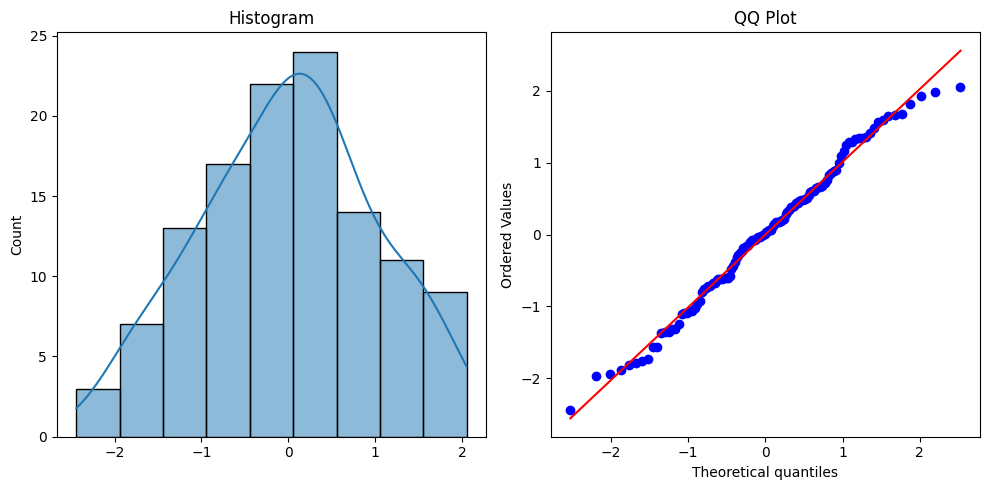

In [94]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Ya, model yang dipaskan sudah tepat.
Berdasarkan histogram yang terbentuk, sisaan terbakukan membentuk distribusi yang cukup simetris menyerupai kurva lonceng normal, dengan puncak yang berpusat di sekitar angka nol. Sementara itu, berdasarkan QQ Plot, titik-titik biru observasi menempel rapat dan mengikuti garis lurus diagonal berwarna merah secara keseluruhan. Tidak ada penyimpangan melengkung yang ekstrem. Kedua plot ini menunjukkan bahwa asumsi normalitas sisaan telah terpenuhi secara visual. Dengan informasi dari plot-plot sisaan sebelumnya, model dummy musiman ini terbukti sangat tepat untuk data tersebut.

Hitunglah statistik uji untuk mengecek asumsi model

- Uji Shapiro-Wilk (Asumsi Normalitas Sisaan)

H0: Sisaan berdistribusi normal.
H1: Sisaan tidak berdistribusi normal.
Nilai p-value = 0.3644.

Karena p-value > 0.05, maka gagal tolak H0. Secara statistik, dapat disimpulkan bahwa sisaan model berdistribusi normal.

- Uji Breusch-Pagan (Asumsi Homoskedastisitas / Ragam Konstan)

H0: Ragam sisaan konstan.
H1: Ragam tidak sisaan konstan.
Nilai p-value = 0.3533.

Karena p-value > 0.05, maka gagal tolak H0. Dapat disimpulkan bahwa ragam sisaan konstan sehingga asumsi homoskedastisitas terpenuhi.

- Uji Ljung-Box (Asumsi Non-Autokorelasi / Sisaan Saling Bebas)

H0: Tidak terdapat autokorelasi pada sisaan.
H1: Terdapat autokorelasi pada sisaan.
Nilai p-value = 0.6781 pada lag 20.

Karena p-value > 0.05, maka gagal tolak H0. Dapat disimpulkan bahwa sisaan saling bebas dan tidak terdapat masalah autokorelasi.

In [95]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

# 1. Uji Normalitas (Shapiro-Wilk)
# H0: Sisaan berdistribusi normal
shapiro_stat, shapiro_p = stats.shapiro(musiman.resid)
print(f"P-value Uji Shapiro-Wilk: {shapiro_p:.4f}")

# 2. Uji Homoskedastisitas (Breusch-Pagan)
# H0: Ragam sisaan konstan (Homoskedastisitas)
# Perbaikan: Menambahkan konstanta sementara khusus untuk syarat fungsi uji BP
exog_bp = sm.add_constant(musiman.model.exog)
bp_test = het_breuschpagan(musiman.resid, exog_bp)
print(f"P-value Uji Breusch-Pagan: {bp_test[1]:.4f}")

# 3. Uji Autokorelasi (Ljung-Box)
# H0: Tidak ada autokorelasi pada sisaan
ljung_box = acorr_ljungbox(musiman.resid, lags=[20], return_df=True)
print(f"P-value Ljung-Box (Lag 20): {ljung_box['lb_pvalue'].values[0]:.4f}")

P-value Uji Shapiro-Wilk: 0.3644
P-value Uji Breusch-Pagan: 0.3533
P-value Ljung-Box (Lag 20): 0.6781


In [96]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [97]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.551e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.60e-309
Time:                        16:32:00   Log-Likelihood:                -255.88
No. Observations:                 120   AIC:                             535.8
Df Residuals:                     108   BIC:                             569.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2206.2205      0.680  -3242.944      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Pada model dengan intersep, angka -2206.2205 bertindak sebagai nilai baseline, yaitu nilai rata-rata estimasi untuk bulan Januari yang dibuang sebelumnya. Pada bulan lainnya, angka-angka koefisiennya kini merepresentasikan selisih atau perbedaan rata-rata nilai bulan tersebut dibandingkan dengan nilai baseline, yaitu nilai pada bulan Januari.

Untuk mendapatkan nilai deret di bulan lainnya, dapat dilakukan penjumlahan antara koefisien bulan tersebut dengan koefisien pada bulan baseline. Secara keseluruhan, model dengan intersep memiliki koefisien yang dapat dibandingkan secara langsung dengan baseline. Misal, nilai deret di bulan Februari diprediksi lebih tinggi 221.8685 unit dibandingkan Januari.

Kedua model dengan atau tanpa intersep secara matematis adalah model yang persis sama, hanya saja cara penyajian informasinya yang berbeda. Keduanya menghasilkan fitted values yang sama persis dan tingkat akurasi (R-squared 1.000) yang sama persis juga.



Apakah model dengan intersep sudah memenuhi asumsi regresi?

Ya, sudah memenuhi. Karena kedua model tersebut menghasilkan fitted values yang sama persis, maka sisaan (residuals) yang dihasilkan juga 100% identik. Berdasarkan syntax berikut yang telah disesuaikan dengan model dengan intersep, didapatkan nilai p-value:
- Uji Shapiro-Wilk: 0.3644 (sisaan model berdistribusi normal)
- Uji Breusch-Pagan: 0.2792 (ragam sisaan konstan sehingga asumsi homoskedastisitas terpenuhi)
- Ljung-Box (Lag 20): 0.6781 (sisaan saling bebas dan tidak terdapat masalah autokorelasi)

Dengan demikian, model dengan intersep sudah memenuhi asumsi regresi.

In [98]:
# uji asumsi model dengan intersep

import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

# 1. Uji Normalitas (Shapiro-Wilk)
shapiro_stat_int, shapiro_p_int = stats.shapiro(musiman_int.resid)
print(f"P-value Uji Shapiro-Wilk: {shapiro_p_int:.4f}")

# 2. Uji Homoskedastisitas (Breusch-Pagan)
# Catatan: Karena 'musiman_int' sudah dibuat dengan sm.add_constant,
# kita tidak perlu menambahkannya lagi secara manual di sini.
bp_test_int = het_breuschpagan(musiman_int.resid, musiman_int.model.exog)
print(f"P-value Uji Breusch-Pagan: {bp_test_int[1]:.4f}")

# 3. Uji Autokorelasi (Ljung-Box)
ljung_box_int = acorr_ljungbox(musiman_int.resid, lags=[20], return_df=True)
print(f"P-value Ljung-Box (Lag 20): {ljung_box_int['lb_pvalue'].values[0]:.4f}")

P-value Uji Shapiro-Wilk: 0.3644
P-value Uji Breusch-Pagan: 0.2792
P-value Ljung-Box (Lag 20): 0.6781


## Kecenderungan Linear dan Musiman

In [99]:
# Parameter
np.random.seed(1094)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*94, 10*94 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


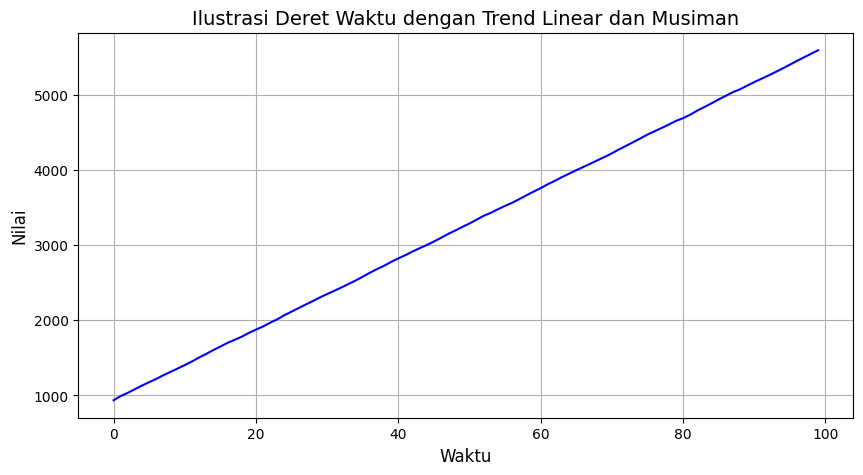

In [100]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [101]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [102]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [103]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.367e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.55e-241
Time:                        16:32:45   Log-Likelihood:                -210.74
No. Observations:                 100   AIC:                             447.5
Df Residuals:                      87   BIC:                             481.3
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      940.1313      0.795   1182.056      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

Koefisien untuk variabel period bernilai 47.0008. Nilai ini merepresentasikan kemiringan (slope) atau laju pertumbuhan linear dari data. Secara rata-rata, nilai deret waktu akan bertambah sebesar sekitar 47 unit untuk setiap penambahan satu periode waktu (satu bulan), dengan asumsi efek musimannya dikendalikan atau bernilai tetap. Nilai regresi ini sangat akurat karena mendeteksi parameter simulasi tren awal, di mana a = 47.

Karena model ini memasukkan 12 variabel dummy secara bersamaan beserta variabel waktu, koefisien bulannya bertindak sebagai nilai dasar sekaligus penangkap fluktuasi. Koefisien tiap bulan menunjukkan estimasi nilai rata-rata deret pada bulan tersebut setelah pengaruh tren kenaikan (period) dihilangkan dari perhitungan. Model ini juga menangkap efek sinusoidal. Berdasarkan nilai koefisien pada bulan-bulan ini, dapat terlihat nilainya beranjak naik dari Januari hingga bulan April, lalu perlahan turun sampai ke bulan Oktober. Fluktuasi nilai koefisien ini mewakili gelombang sinusoidal.

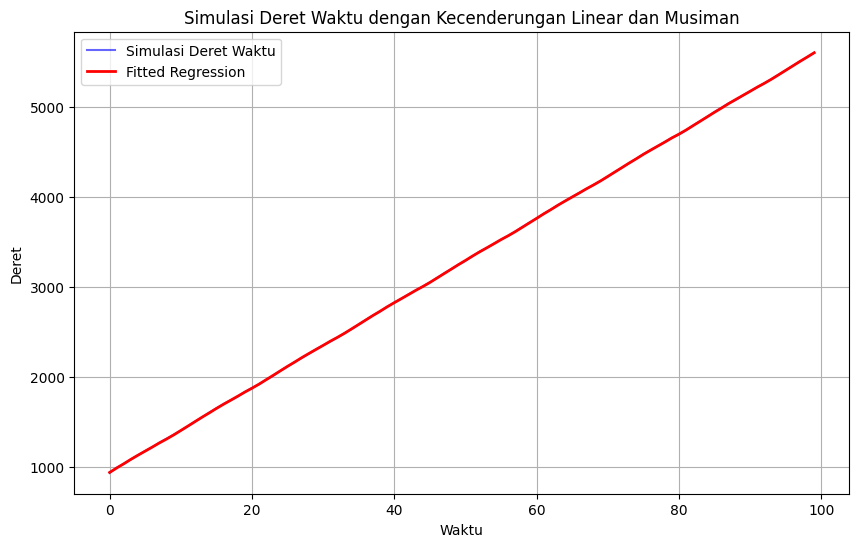

In [104]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

Dengan tingkat signifikansi 0.05, maka dilakukan beberapa uji asumsi berikut.

- Uji Shapiro-Wilk (Asumsi Normalitas Sisaan)

H0: Sisaan berdistribusi normal.
H1: Sisaan tidak berdistribusi normal.
Nilai p-value = 0.5006.

Karena p-value > 0.05, maka gagal tolak H0. Secara statistik, dapat disimpulkan bahwa sisaan model berdistribusi normal.

- Uji Breusch-Pagan (Asumsi Homoskedastisitas / Ragam Konstan)

H0: Ragam sisaan konstan.
H1: Ragam tidak sisaan konstan.
Nilai p-value = 0.3838.

Karena p-value > 0.05, maka gagal tolak H0. Dapat disimpulkan bahwa ragam sisaan konstan sehingga asumsi homoskedastisitas terpenuhi.

- Uji Ljung-Box (Asumsi Non-Autokorelasi / Sisaan Saling Bebas)

H0: Tidak terdapat autokorelasi pada sisaan.
H1: Terdapat autokorelasi pada sisaan.
Nilai p-value = 0.8192 pada lag 20.

Karena p-value > 0.05, maka gagal tolak H0. Dapat disimpulkan bahwa sisaan saling bebas dan tidak terdapat masalah autokorelasi.

Dengan demikian, hasil menunjukkan bahwa tidak ada pelanggaran asumsi dalam model.

In [105]:
# uji asumsi model

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

# 1. Uji Normalitas Sisaan
shapiro_stat_mix, shapiro_p_mix = stats.shapiro(model_mix.resid)
print(f"P-value Uji Shapiro-Wilk: {shapiro_p_mix:.4f}")

# 2. Uji Homoskedastisitas
# Karena model_mix tidak punya konstanta umum (menggunakan dummy bulan lengkap),
# kita tambahkan konstanta sementara khusus untuk uji BP.
exog_bp_mix = sm.add_constant(model_mix.model.exog)
bp_test_mix = het_breuschpagan(model_mix.resid, exog_bp_mix)
print(f"P-value Uji Breusch-Pagan: {bp_test_mix[1]:.4f}")

# 3. Uji Autokorelasi
ljung_box_mix = acorr_ljungbox(model_mix.resid, lags=[20], return_df=True)
print(f"P-value Ljung-Box (Lag 20): {ljung_box_mix['lb_pvalue'].values[0]:.4f}")

P-value Uji Shapiro-Wilk: 0.5006
P-value Uji Breusch-Pagan: 0.3838
P-value Ljung-Box (Lag 20): 0.8192


Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [106]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

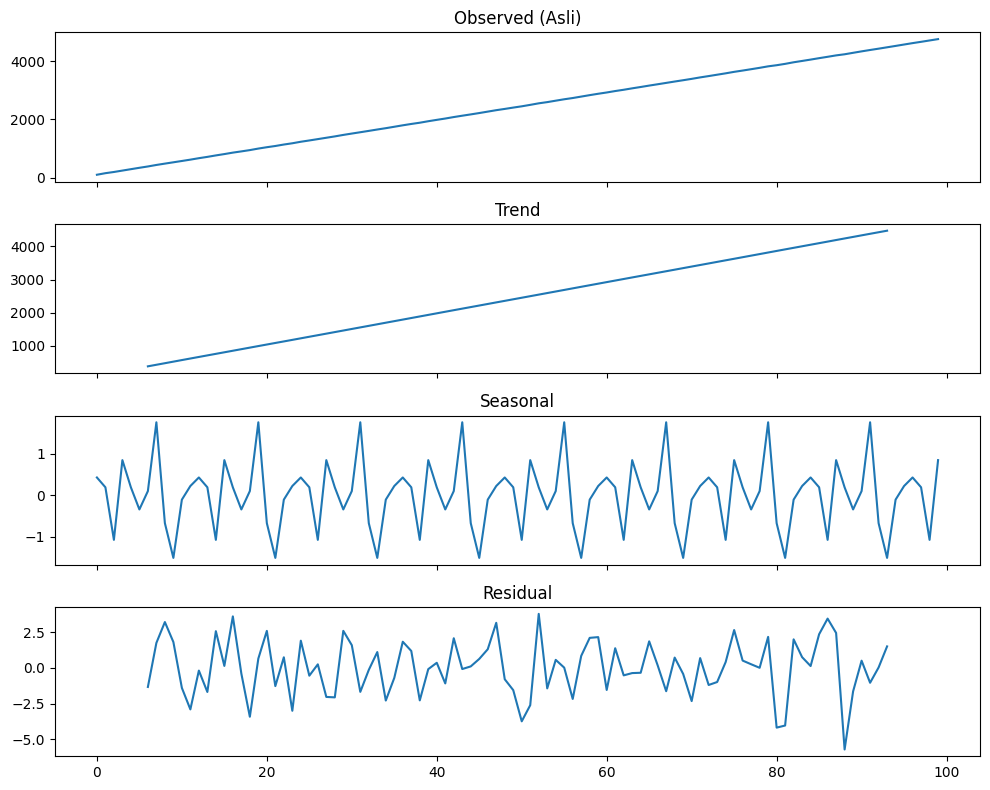

In [107]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

1. Observed (Asli) : Plot ini menampilkan data mentah persis seperti aslinya, sebelum dipisahkan. Terlihat bahwa deret ini didominasi oleh tren linear yang kuat dan bergerak naik dari nilai mendekati 0 hingga hampir mencapai 10.000 seiring waktu.

2. Trend: Plot ini menunjukkan komponen tren murni yang telah dibersihkan dari noise dan musiman. Bentuknya merupakan garis lurus sempurna yang menanjak ke atas. Ini mengonfirmasi bahwa pola utama yang menggerakkan deret ini adalah tren linear murni. Rentang nilainya sangat besar, mengikuti pola pada plot Observed.

3. Seasonal: Plot ini merupakan pola musiman yang berulang setiap 12 periode. Dalam kasus ini, fungsi dekomposisi dipaksa untuk mencari pola yang berulang setiap 12 periode karena adanya parameter period=12. Meskipun terlihat ada pola gelombang yang berulang, namun skala pada sumbu Y hanya berkisar dari -1 hingga 1. Hal ini menunjukkan nilai musiman ini sangat kecil. Jika dibandingkan dengan skala tren yang mencapai ribuan, fluktuasi sekecil ini sebenarnya dapat diabaikan karena tidak berpengaruh secara signifikan. Dapat terlihat pula dalam plot bahwa tidak ada pola seasonal yang jelas dalam data ini.

4. Residual: Plot ini menampilkan sisa dari data asli setelah komponen tren dan musiman dikeluarkan. Bentuknya terlihat berfluktuasi secara acak di sekitar angka 0, di antara rentang sekitar -5 hingga 5. Ini mencerminkan komponen acak yang ada dalam simulasi.

In [108]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

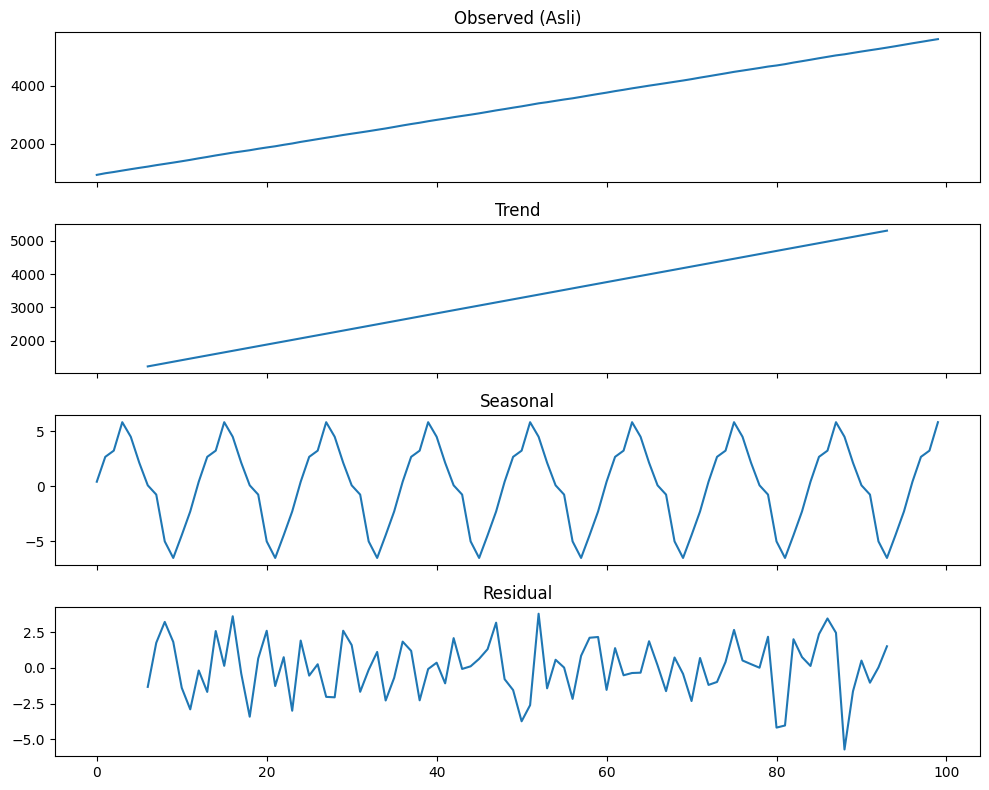

In [109]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

1. Observed (Asli): Plot ini menampilkan data gabungan secara keseluruhan. Terlihat bahwa deret ini didominasi oleh tren linear yang kuat dan bergerak naik dari skala 1000 hingga 5000. Karena komponen trennya sangat besar dibandingkan dengan musimannya, data ini terlihat seperti garis lurus biasa. Pola musiman data ini tertutup oleh trennya yang kuat.

2. Trend: Algoritma dekomposisi memisahkan komponen pertumbuhan linear dengan baik. Garis tren yang dihasilkan merepresentasikan laju pertumbuhan yang terus naik.

3. Seasonal: Plot musiman ini menunjukkan pola gelombang periodik yang sangat teratur dan mulus. Rentang nilainya bergerak dari -5 hingga 5. Hal ini cocok dengan komponen musiman sinusoidal yang telah dibuat sebelumnya. Hal ini menunjukkan bahwa algoritma dekomposisi yang dilakukan dapat memisahkan komponen trend dan seasonal dengan baik.

4. Residual: Plot ini menunjukkan sisaan setelah tren dan musiman dikeluarkan dari data asli. Hasilnya adalah fluktuasi yang sepenuhnya acak menyebar di sekitar angka 0, di antara -5 hingga 5. Plot ini mencerminkan komponen acak yang ada dalam simulasi.



Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [110]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1094)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05 * 94, 10 * 94 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

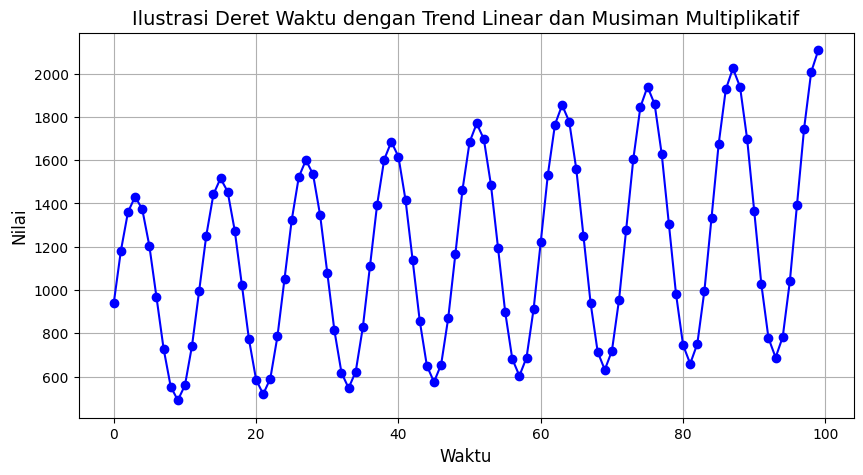

In [111]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [112]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

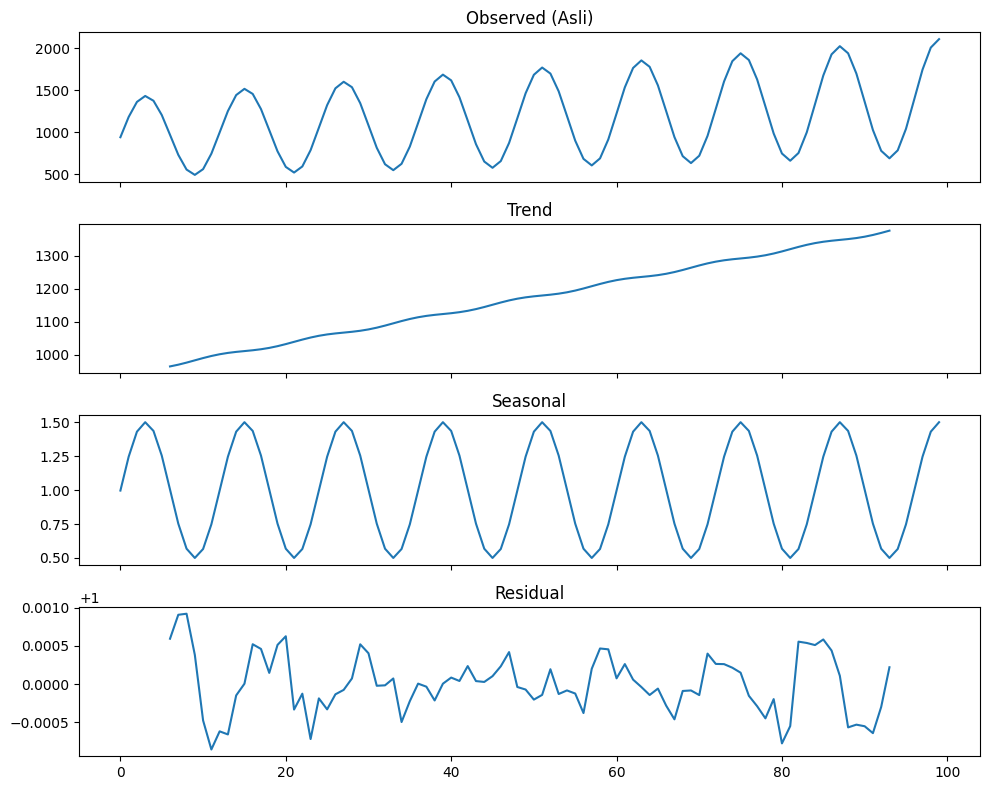

In [113]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

1. Observed (Asli) : Berbeda dengan plot deret sebelumnya, pada plot ini terlihat bahwa tinggi-rendahnya amplitudo semakin membesar ke kanan seiring dengan bertambahnya waktu dan tren. Di awal waktu, fluktuasinya lebih sempit. Di akhir waktu, amplitudonya menjadi jauh lebih lebar. Ini adalah ciri khas utama data multiplikatif.
2. Trend : Algoritma berhasil memisahkan komponen pertumbuhan jangka panjang dari data. Garisnya menunjukkan tren yang terus menanjak naik dengan stabil dari nilai di bawah 1000 hingga sekitar 1350.
3. Seasonal : Pada saat puncak musim (nilai 1.5), nilai deret adalah 1.5 kali lipat dari garis tren. Sebaliknya, pada saat dasar musim (nilai 0.5), nilainya hanya 0.5 kali lipat dari garis tren. Hal ini menunjukkan alasan gelombang aslinya makin membesar saat trennya makin tinggi.
4. Residual : Sisaan pada model multiplikatif secara teoretis berpusat di angka 1.0. Pada plot, sisaannya bergerak di sekitar angka 1 (antara 0.9995 hingga 1.0010). Fluktuasinya sangat amat kecil karena noise acak yang dimasukkan memiliki scale=0.2 menjadi pecahan desimal yang sangat kecil ketika dibandingkan dengan nilai data yang besarnya ribuan.

In [114]:
# Parameter
np.random.seed(1094)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

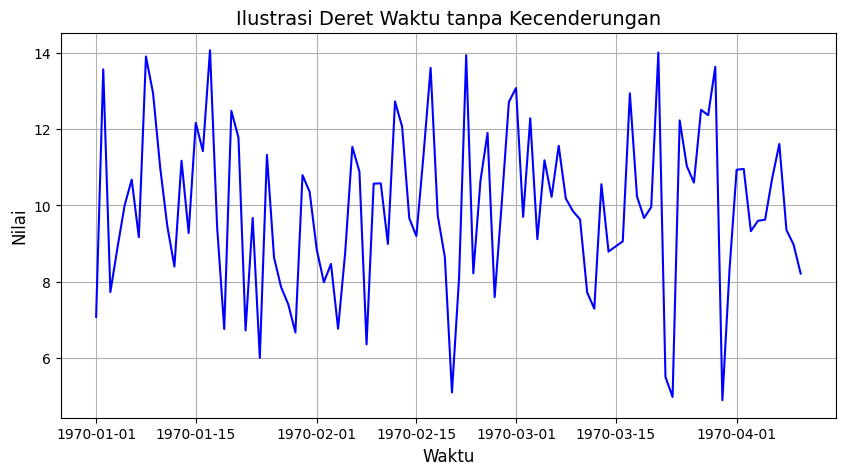

In [115]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

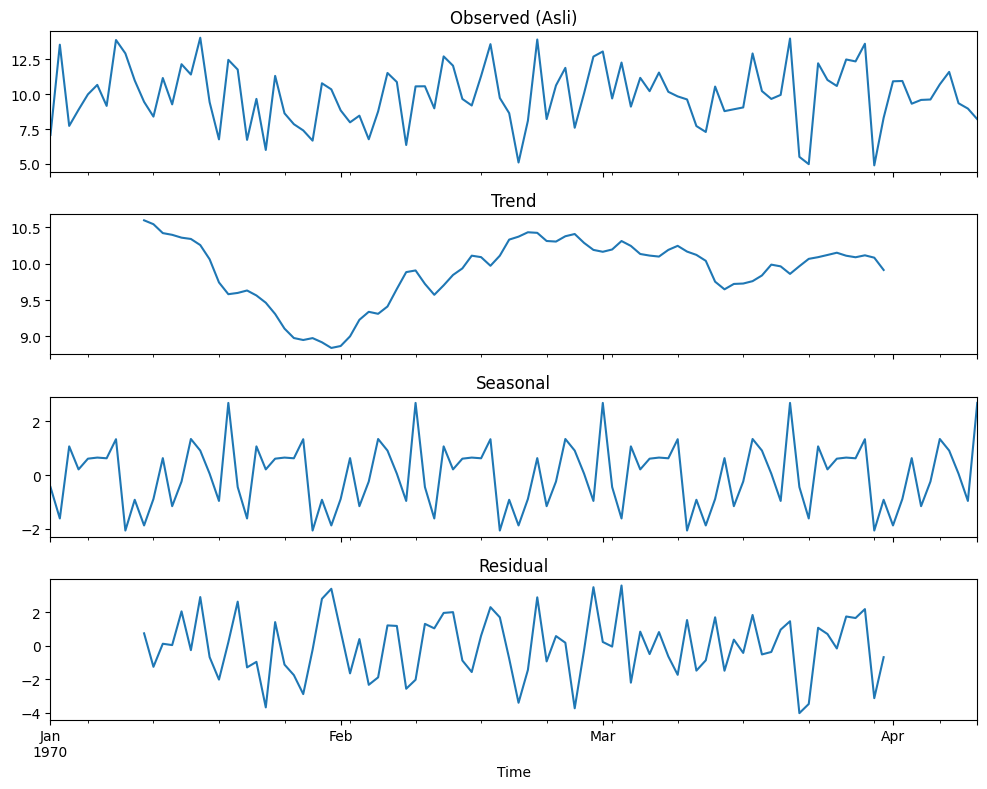

In [116]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

1. Observed (Asli) : Plot data asli menunjukkan pergerakan deret yang sepenuhnya acak di sekitar rata-rata 10 tanpa adanya pola arah jangka panjang berupa tren maupun pola musiman. Plot ini menampilkan data mentah yang berupa fluktuasi acak murni. Nilainya naik-turun secara tidak teratur di sekitar angka 10.

2. Trend : Garis yang dihasilkan tampak bergelombang secara acak tanpa arah yang jelas. Arah garis tidak konsisten naik atau turun. Karena data yang digunakan dalam plot ini murni acak, maka hasil tren ini menjadi berupa variasi di sekitar nilai tengah. Karena datanya merupakan angka acak, tren yang digunakan dalam plot ini berupa rata-rata bergerak (moving average) dari keacakan tersebut. Dapat terlihat dalam plot bahwa tidak ada pola tren yang jelas dalam data ini.

3. Seasonal : Dalam kasus ini, fungsi dekomposisi dipaksa untuk mencari pola yang berulang setiap 20 periode karena adanya parameter period=20. Hasilnya adalah gelombang seasonal buatan yang diekstrak secara paksa dari tumpukan data acak tersebut. Dapat terlihat dalam plot bahwa tidak ada pola seasonal yang jelas dalam data ini.

4. Residual : Plot sisaan ini terlihat berfluktuasi bebas dan sangat mirip dengan karakteristik plot Observed di atasnya. Hal ini membuktikan bahwa setelah komponen tren dan musiman tadi dikeluarkan, struktur utama pembentuk data ini memang hanyalah sisaan atau random noise itu sendiri.